#  Level 1: Scientific Problem Framing & Python Foundation

## HydroSense-Kenya — Smart Irrigation Decision Support System

**ICS 2207 Scientific Computing | Capstone Project**

---

> *"The goal of computing is insight, not numbers."* — Richard Hamming

This notebook establishes the computational foundation for HydroSense-Kenya: translating a real-world agricultural water management challenge into a mathematically precise, computationally tractable problem.

**Objectives:**
1. Define the scientific problem in a Kenyan agricultural context
2. Establish the mathematical model and its assumptions
3. Load and inspect the sensor datasets
4. Implement core reusable functions (ET computation, water balance)
5. Produce initial diagnostic visualisations
6. Document assumptions and their implications

---

## 1. Scientific Problem Statement

### 1.1 Context: Water Scarcity in Kenyan Agriculture

Kenya's agricultural sector accounts for approximately 33% of GDP and employs over 40% of the total population, yet it operates under severe hydrological constraints. The country is classified as chronically water-scarce, with per-capita renewable freshwater availability below 500 m³/year—well under the UN threshold of 1,000 m³/year. In the semi-arid and sub-humid regions where smallholder farming dominates, rainfall is the primary water input, but its high inter-annual and intra-seasonal variability makes rainfed agriculture unreliable.

Irrigation offers a pathway to stabilise yields, but water-use efficiency on Kenyan smallholder farms remains low: field application efficiencies often fall below 50%, meaning more than half of applied water is lost to deep drainage, surface runoff, or non-productive evaporation. This inefficiency is not merely an economic problem—it depletes aquifers, degrades soil structure through waterlogging, and accelerates salinisation in vulnerable zones.

### 1.2 The Computational Problem

The central scientific question is:

> **Given daily weather observations and soil-sensor readings from a demonstration farm, how can we model soil water availability, estimate crop water deficit, simulate future soil moisture under rainfall uncertainty, and recommend an irrigation schedule that minimises water use without exposing crops to moisture stress?**

This question decomposes into four coupled computational sub-problems:

1. **Estimation**: Compute daily evapotranspiration (ET) from meteorological drivers using a simplified empirical model, then estimate the soil water balance.

2. **Prediction**: Propagate the water balance equation forward in time using numerical ODE integrators (Euler, Runge-Kutta), producing soil moisture trajectories under deterministic forcing.

3. **Uncertainty quantification**: Generate stochastic rainfall scenarios via Monte Carlo simulation, producing an ensemble of moisture trajectories that capture the probabilistic range of future outcomes.

4. **Optimisation**: Find the irrigation schedule that minimises total water application while maintaining soil moisture above crop-specific stress thresholds—a constrained optimisation problem with coupled dynamics.

### 1.3 Why This Matters Computationally

This problem is not a textbook exercise. It integrates:
- **Floating-point sensitivity**: The ET formula involves subtraction of terms of similar magnitude, creating potential for catastrophic cancellation when humidity is high and temperature is low.
- **Stiffness considerations**: The drainage term introduces a fast timescale (drainage coefficient α ≈ 0.15–0.22 day⁻¹) that can destabilise explicit ODE integrators if the time step is too large.
- **Ill-conditioning**: The multi-zone water allocation problem (Ax = b) may have a poorly conditioned coefficient matrix when zone parameters are similar, amplifying measurement errors in the solution.
- **Decision under uncertainty**: Monte Carlo simulation produces not a single recommendation but a distribution of outcomes—the decision-maker must choose a risk tolerance.

---

## 2. Mathematical Model

### 2.1 Discrete Water Balance Equation

The soil water storage $S$ (% volumetric) evolves according to:

$$S_{t+1} = S_t + R_t + I_t - ET_t - D_t$$

| Symbol | Meaning | Units | Source |
|--------|---------|-------|--------|
| $S_t$ | Soil water storage at time $t$ | % vol. | Sensor measurement |
| $R_t$ | Rainfall contribution | mm/day | Weather station |
| $I_t$ | Irrigation applied | mm/day | Control variable |
| $ET_t$ | Evapotranspiration (crop water loss) | mm/day | Computed from weather |
| $D_t$ | Drainage beyond field capacity | mm/day | Model-derived |

### 2.2 Evapotranspiration Model

$$ET = \max\left(0,\; 0.12T + 0.35W + 2.4 \cdot \text{Solar} - 0.025H\right)$$

**Coefficient interpretation:**
- $0.12T$: Temperature drives saturation vapour pressure; each °C adds ≈0.12 mm/day to ET demand
- $0.35W$: Wind enhances boundary-layer conductance, accelerating moisture transport from leaf to atmosphere
- $2.4 \cdot \text{Solar}$: Radiation provides the energy for phase change (latent heat flux)
- $-0.025H$: Humidity reduces the vapour pressure deficit, suppressing evaporative demand
- $\max(0, \cdot)$: Physical constraint — ET cannot be negative (condensation is negligible at this timescale)

### 2.3 Drainage Model

$$D_t = \alpha \cdot \max(0,\; S_t - S_{fc})$$

Where $\alpha$ is the drainage coefficient (day⁻¹) and $S_{fc}$ is field capacity. This is a linear reservoir model: drainage is proportional to the excess moisture above field capacity, with the rate controlled by soil texture (sandy soils drain faster, hence larger α).

---

## 3. Computational Setup

In [1]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add source directory to path
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))

from simulation import compute_et, compute_drainage, water_balance_rhs
from visualization import setup_publication_style, COLORS, ZONE_COLORS

setup_publication_style()

# Reproducibility
np.random.seed(42)

print("HydroSense-Kenya — Level 1: Problem Framing")
print(f"NumPy version  : {np.__version__}")
print(f"Pandas version : {pd.__version__}")
print("Setup complete ✓")

HydroSense-Kenya — Level 1: Problem Framing
NumPy version  : 2.4.2
Pandas version : 3.0.1
Setup complete ✓


---

## 4. Dataset Loading and Inspection

We have three datasets from a demonstration farm, covering 30 days of March 2026. These datasets are intentionally imperfect — missing values, sensor faults, and outliers are present by design, reflecting the reality of agricultural sensor networks.

In [2]:
# Load datasets with explicit NA handling
weather = pd.read_csv("../data/raw/weather_daily.csv", na_values=["NA", ""])
soil = pd.read_csv("../data/raw/soil_sensor_data.csv", na_values=["NA", ""])
params = pd.read_csv("../data/raw/crop_zone_parameters.csv", na_values=["NA", ""])

print("=" * 65)
print("WEATHER DAILY — Structure")
print("=" * 65)
print(f"Shape: {weather.shape[0]} days × {weather.shape[1]} variables")
print(f"Date range: {weather['date'].iloc[0]} to {weather['date'].iloc[-1]}")
print()
weather.info()

WEATHER DAILY — Structure
Shape: 30 days × 6 variables
Date range: 2026-03-01 to 2026-03-30

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            30 non-null     str    
 1   rainfall_mm     29 non-null     float64
 2   temperature_c   30 non-null     float64
 3   humidity_pct    29 non-null     float64
 4   wind_speed_mps  30 non-null     float64
 5   solar_index     30 non-null     float64
dtypes: float64(5), str(1)
memory usage: 1.5 KB


In [3]:
print("=" * 65)
print("SOIL SENSOR DATA — Structure")
print("=" * 65)
print(f"Shape: {soil.shape[0]} records ({soil.shape[0]//3} days × 3 zones)")
print(f"Zones: {soil['zone_id'].unique().tolist()}")
print()
soil.info()

SOIL SENSOR DATA — Structure
Shape: 90 records (30 days × 3 zones)
Zones: ['Zone_A', 'Zone_B', 'Zone_C']

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   timestamp          90 non-null     str    
 1   zone_id            90 non-null     str    
 2   soil_moisture_pct  90 non-null     float64
 3   tank_level_liters  90 non-null     int64  
 4   pump_flow_lpm      90 non-null     float64
 5   pump_power_watts   90 non-null     int64  
 6   sensor_status      90 non-null     str    
dtypes: float64(2), int64(2), str(3)
memory usage: 5.1 KB


In [4]:
print("=" * 65)
print("CROP ZONE PARAMETERS")
print("=" * 65)
print()
params.style.set_caption("Farm Zone Configuration")
print(params.to_string(index=False))

CROP ZONE PARAMETERS

zone_id crop_type  area_m2  min_moisture_pct  target_moisture_pct  field_capacity_pct  drainage_coefficient
 Zone_A    tomato      120                22                   33                  41                  0.18
 Zone_B      kale       90                24                   35                  43                  0.15
 Zone_C     maize      180                20                   31                  40                  0.22


---

## 5. Data Dictionary

### 5.1 Weather Variables

| Variable | Type | Units | Range | Physical Meaning |
|----------|------|-------|-------|-----------------|
| `date` | datetime | — | 2026-03-01 to 2026-03-30 | Observation date |
| `rainfall_mm` | float | mm/day | 0 – 85+ | Daily precipitation (tipping-bucket gauge) |
| `temperature_c` | float | °C | 21 – 46 | Mean daily air temperature (thermistor) |
| `humidity_pct` | float | % | 56 – 75 | Relative humidity (capacitive sensor) |
| `wind_speed_mps` | float | m/s | 1.1 – 3.1 | Wind speed at 2m height (cup anemometer) |
| `solar_index` | float | [0, 1] | 0.49 – 0.80 | Normalised clear-sky radiation fraction |

### 5.2 Soil Sensor Variables

| Variable | Type | Units | Range | Physical Meaning |
|----------|------|-------|-------|-----------------|
| `timestamp` | datetime | — | — | Noon daily reading |
| `zone_id` | string | — | A, B, C | Farm zone identifier |
| `soil_moisture_pct` | float | % vol. | 8.5 – 36 | Volumetric water content (TDR probe) |
| `tank_level_liters` | float | L | 3369 – 9900 | Water storage tank level |
| `pump_flow_lpm` | float | L/min | 0 – 29 | Irrigation pump flow rate |
| `pump_power_watts` | float | W | 394 – 523 | Pump electrical consumption |
| `sensor_status` | string | — | OK/CHECK | Automated sensor health flag |

### 5.3 Crop Zone Parameters

| Variable | Type | Units | Meaning |
|----------|------|-------|---------|
| `zone_id` | string | — | Zone identifier |
| `crop_type` | string | — | Crop species grown |
| `area_m2` | int | m² | Zone cultivated area |
| `min_moisture_pct` | float | % vol. | Wilting point threshold |
| `target_moisture_pct` | float | % vol. | Optimal irrigation target |
| `field_capacity_pct` | float | % vol. | Maximum retention before drainage |
| `drainage_coefficient` | float | day⁻¹ | Gravitational drainage rate |

---

## 6. Core Reusable Functions

These functions form the computational backbone of HydroSense-Kenya. They are defined in `src/simulation.py` and imported here. Below we demonstrate their usage and verify basic correctness.

In [5]:
# Demonstrate ET computation with sample data
sample_temp = np.array([23.8, 25.9, 26.8, 27.0, 26.6])
sample_wind = np.array([2.28, 1.62, 2.11, 2.09, 1.36])
sample_solar = np.array([0.78, 0.71, 0.75, 0.58, 0.62])
sample_humidity = np.array([69.7, 62.0, 64.4, 64.6, 61.0])

et_values = compute_et(sample_temp, sample_wind, sample_solar, sample_humidity)

print("Evapotranspiration Computation — First 5 Days")
print("-" * 55)
print(f"{'Day':<6} {'T (°C)':<10} {'W (m/s)':<10} {'Solar':<8} {'H (%)':<8} {'ET (mm)':<10}")
print("-" * 55)
for i in range(5):
    print(f"{i+1:<6} {sample_temp[i]:<10.1f} {sample_wind[i]:<10.2f} "
          f"{sample_solar[i]:<8.2f} {sample_humidity[i]:<8.1f} {et_values[i]:<10.4f}")

print(f"\nMean ET: {et_values.mean():.4f} mm/day")
print(f"Range:   [{et_values.min():.4f}, {et_values.max():.4f}] mm/day")

# Verify non-negativity
assert np.all(et_values >= 0), "ET must be non-negative!"
print("\n✓ All ET values are non-negative (physical constraint satisfied)")

Evapotranspiration Computation — First 5 Days
-------------------------------------------------------
Day    T (°C)     W (m/s)    Solar    H (%)    ET (mm)   
-------------------------------------------------------
1      23.8       2.28       0.78     69.7     3.7835    
2      25.9       1.62       0.71     62.0     3.8290    
3      26.8       2.11       0.75     64.4     4.1445    
4      27.0       2.09       0.58     64.6     3.7485    
5      26.6       1.36       0.62     61.0     3.6310    

Mean ET: 3.8273 mm/day
Range:   [3.6310, 4.1445] mm/day

✓ All ET values are non-negative (physical constraint satisfied)


In [6]:
# Demonstrate water balance step
s_current = 30.0  # Current soil moisture (%)
rainfall = 5.0     # Today's rainfall (mm)
irrigation = 2.0   # Irrigation applied (mm)
et = 3.5           # Today's ET (mm)
field_cap = 41.0   # Field capacity (%)
drain_coeff = 0.18 # Drainage coefficient (day⁻¹)

dsdt = water_balance_rhs(s_current, rainfall, irrigation, et, field_cap, drain_coeff)
s_next = s_current + dsdt

print("Water Balance Step — Single Day Example")
print("=" * 50)
print(f"  Current moisture S(t)  : {s_current:.1f} %")
print(f"  Rainfall R(t)          : {rainfall:.1f} mm")
print(f"  Irrigation I(t)        : {irrigation:.1f} mm")
print(f"  Evapotranspiration ET  : {et:.1f} mm")
print(f"  Drainage D(t)          : {compute_drainage(s_current, field_cap, drain_coeff):.4f} mm")
print(f"  dS/dt                  : {dsdt:.4f} mm/day")
print(f"  Next moisture S(t+1)   : {s_next:.4f} %")
print()
print("  Mass balance check:")
print(f"    Input  (R + I)       : {rainfall + irrigation:.1f} mm")
print(f"    Output (ET + D)      : {et + compute_drainage(s_current, field_cap, drain_coeff):.4f} mm")
print(f"    Net change           : {dsdt:.4f} mm")

Water Balance Step — Single Day Example
  Current moisture S(t)  : 30.0 %
  Rainfall R(t)          : 5.0 mm
  Irrigation I(t)        : 2.0 mm
  Evapotranspiration ET  : 3.5 mm
  Drainage D(t)          : 0.0000 mm
  dS/dt                  : 3.5000 mm/day
  Next moisture S(t+1)   : 33.5000 %

  Mass balance check:
    Input  (R + I)       : 7.0 mm
    Output (ET + D)      : 3.5000 mm
    Net change           : 3.5000 mm


---

## 7. Initial Diagnostic Visualisation

Our first plot examines the raw rainfall and soil moisture time series to identify patterns, anomalies, and data quality issues before any cleaning is applied.

**What to look for:**
- Temporal correlation between rainfall events and soil moisture response
- Anomalous values that may indicate sensor malfunction
- Missing data gaps
- Differences in moisture dynamics across farm zones

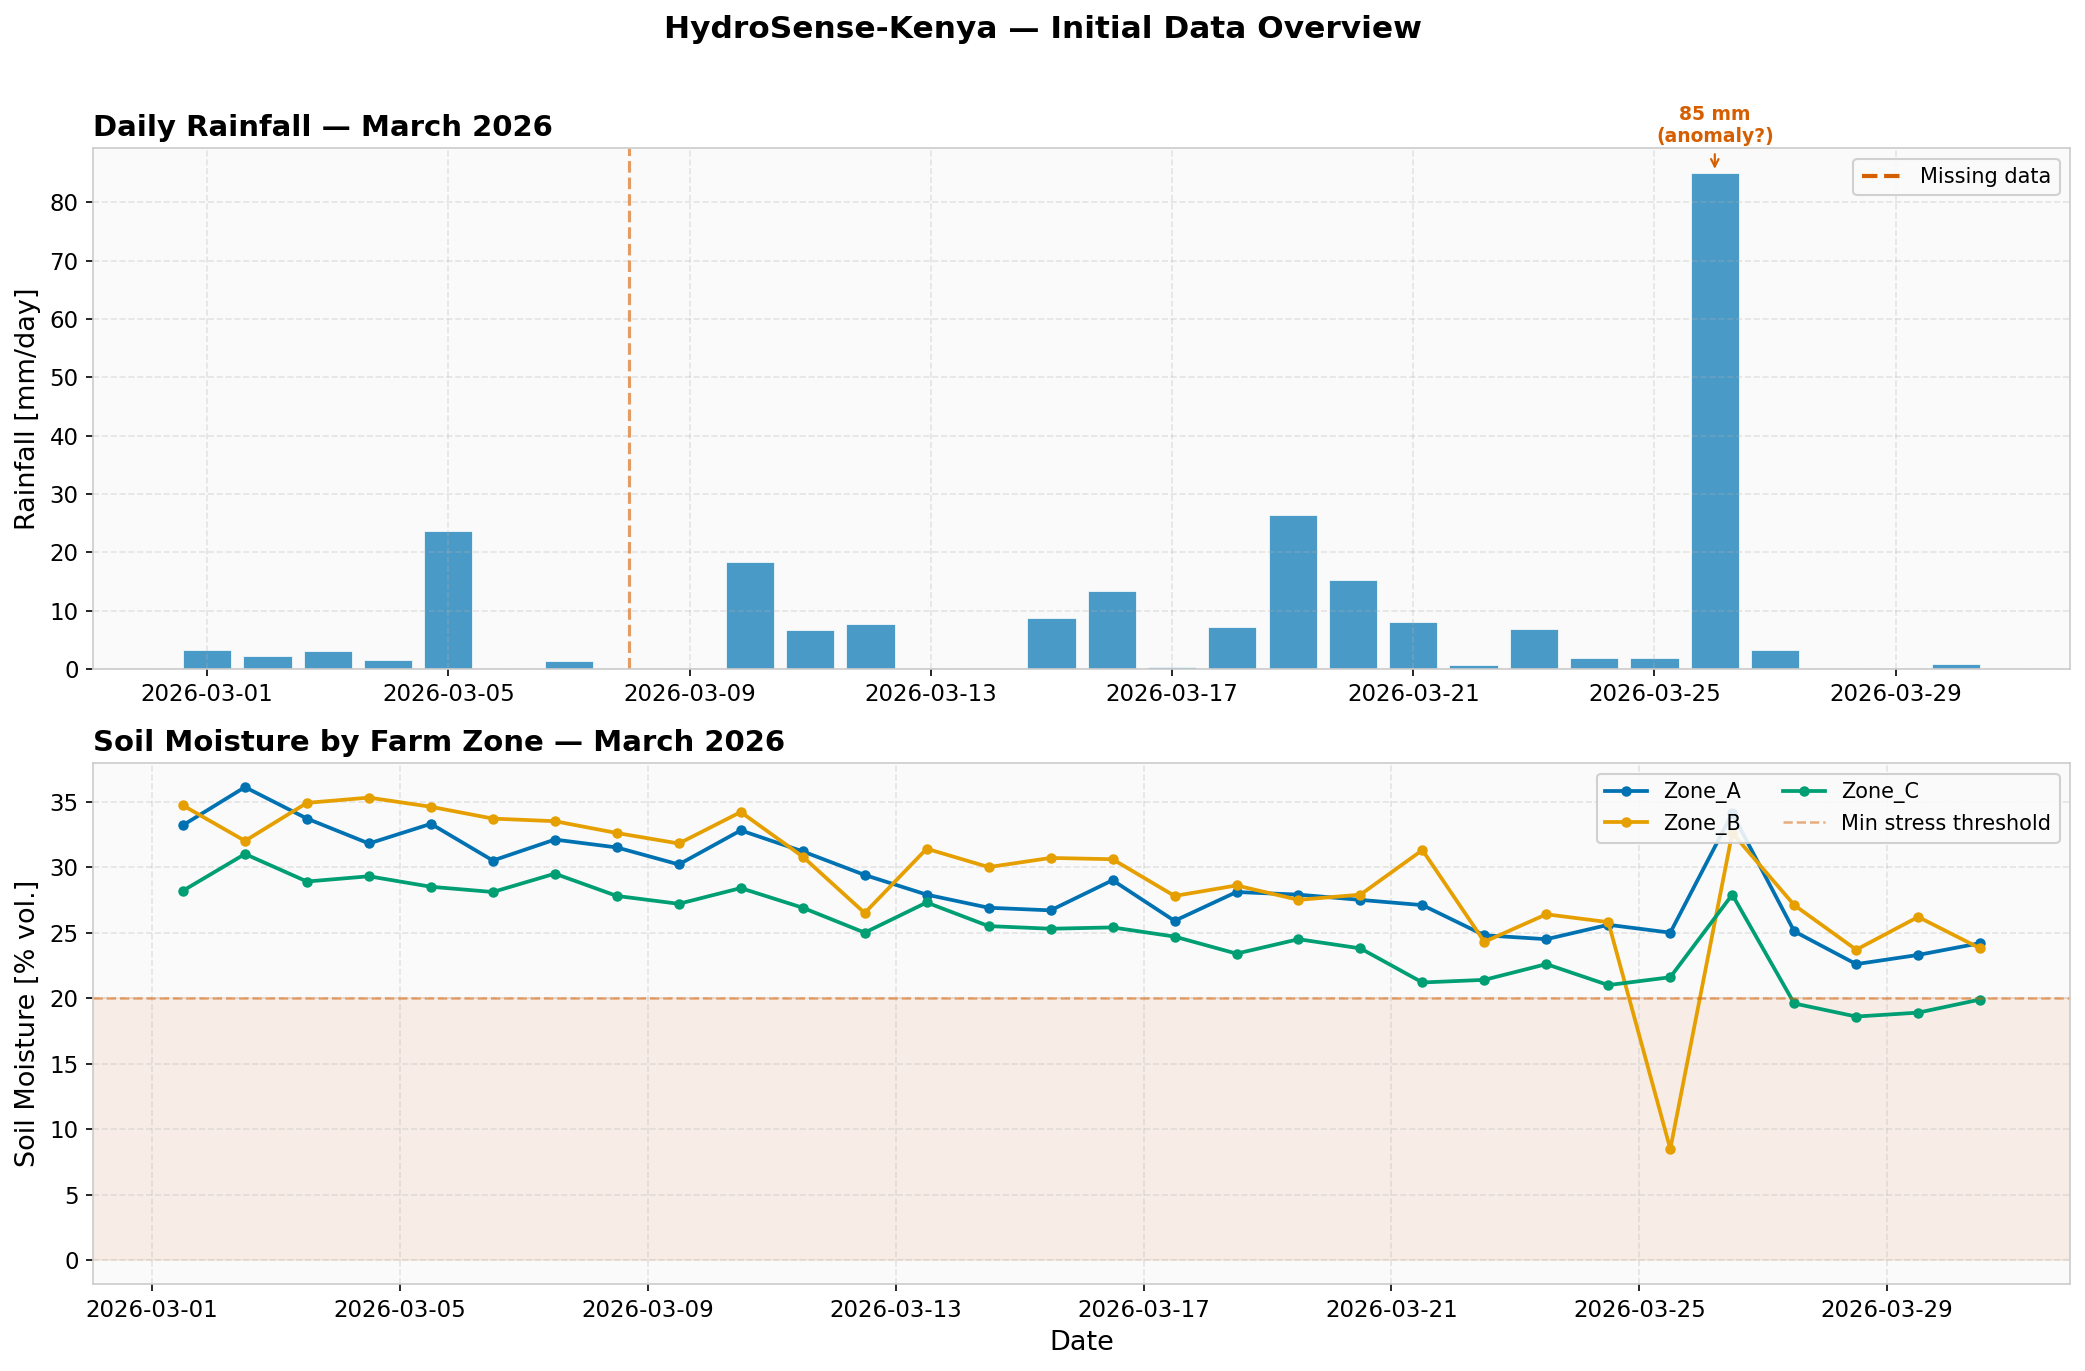


📊 Key observations:
  • Rainfall on March 26 (85 mm) is ~4× the next-largest event — likely a sensor anomaly or extreme event
  • March 8 rainfall is missing (NA) — requires imputation
  • March 21 humidity is missing — affects ET computation for that day
  • Zone_B shows a sharp moisture drop around March 25 (8.5%) — possible sensor fault
  • All zones show a declining moisture trend from March 20 onward — consistent with dry spell


In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=False)

# --- Rainfall time series ---
dates_w = pd.to_datetime(weather['date'])
rainfall = weather['rainfall_mm']

colors_rain = [COLORS['red'] if pd.isna(v) else COLORS['blue'] for v in rainfall]
ax1.bar(dates_w, rainfall.fillna(0), color=COLORS['blue'], alpha=0.7,
        edgecolor='white', linewidth=0.5, width=0.8)

# Mark missing values
missing_mask = rainfall.isna()
if missing_mask.any():
    for d in dates_w[missing_mask]:
        ax1.axvline(d, color=COLORS['red'], alpha=0.6, linestyle='--', linewidth=1.5)
    ax1.plot([], [], color=COLORS['red'], linestyle='--', label='Missing data')

# Mark potential outliers
outlier_mask = rainfall > 50
if outlier_mask.any():
    for d, v in zip(dates_w[outlier_mask], rainfall[outlier_mask]):
        ax1.annotate(f'{v:.0f} mm\n(anomaly?)', xy=(d, v),
                     xytext=(0, 15), textcoords='offset points',
                     fontsize=9, color=COLORS['red'], fontweight='bold',
                     ha='center', arrowprops=dict(arrowstyle='->', color=COLORS['red']))

ax1.set_ylabel('Rainfall [mm/day]')
ax1.set_title('Daily Rainfall — March 2026', loc='left', fontweight='bold')
ax1.legend(loc='upper right')

# --- Soil moisture by zone ---
soil['timestamp'] = pd.to_datetime(soil['timestamp'])
for zone, color in ZONE_COLORS.items():
    zone_data = soil[soil['zone_id'] == zone]
    ax2.plot(zone_data['timestamp'], zone_data['soil_moisture_pct'],
             color=color, marker='o', markersize=4, linewidth=1.8, label=zone)

# Add threshold band
ax2.axhspan(0, params['min_moisture_pct'].min(), alpha=0.08, color=COLORS['red'])
ax2.axhline(params['min_moisture_pct'].min(), color=COLORS['red'],
            linestyle='--', alpha=0.5, linewidth=1.2, label='Min stress threshold')

ax2.set_xlabel('Date')
ax2.set_ylabel('Soil Moisture [% vol.]')
ax2.set_title('Soil Moisture by Farm Zone — March 2026', loc='left', fontweight='bold')
ax2.legend(loc='upper right', ncol=2)

fig.suptitle('HydroSense-Kenya — Initial Data Overview',
             fontsize=15, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

print("\n📊 Key observations:")
print("  • Rainfall on March 26 (85 mm) is ~4× the next-largest event — likely a sensor anomaly or extreme event")
print("  • March 8 rainfall is missing (NA) — requires imputation")
print("  • March 21 humidity is missing — affects ET computation for that day")
print("  • Zone_B shows a sharp moisture drop around March 25 (8.5%) — possible sensor fault")
print("  • All zones show a declining moisture trend from March 20 onward — consistent with dry spell")

---

## 8. Assumptions and Limitations

Every computational model makes simplifying assumptions. Documenting these is essential for scientific integrity — they define the *domain of validity* of our results.

| # | Assumption | Justification | What It Costs |
|---|-----------|---------------|---------------|
| 1 | ET is a linear function of T, W, Solar, H | Linearisation of Penman-Monteith for teaching; captures dominant sensitivities | Ignores nonlinear feedbacks (e.g., stomatal closure at T > 35°C) |
| 2 | Rainfall is spatially uniform across the farm | Farm area ≈ 390 m² — small enough that spatial rainfall gradients are negligible | Fails for farms > 1 ha or during convective storms |
| 3 | Drainage is proportional to excess above field capacity | Standard linear reservoir assumption in operational hydrology | Ignores preferential flow (macropore drainage) |
| 4 | Daily time step is adequate | Soil moisture responds on timescales of hours to days; daily resolution captures dominant dynamics | Cannot resolve sub-daily irrigation scheduling |
| 5 | Sensor readings are point-representative | Single probe per zone is treated as representative of the entire zone | Soil moisture has high spatial variability (coefficient of variation ≈ 20–40%) |
| 6 | No lateral water movement between zones | Zones are treated as independent water buckets | Ignores surface runoff from Zone A to Zone C (topographic gradient) |
| 7 | Crop water uptake is implicitly captured by ET | The ET formula does not distinguish bare-soil evaporation from transpiration | Under-estimates ET during peak vegetative growth, over-estimates during fallow |

### Critical limitation

The simplified ET model has **no crop coefficient** ($K_c$). In the FAO-56 framework, actual ET = $K_c \times ET_0$, where $K_c$ varies from 0.3 (seedling) to 1.2 (mid-season). Our model effectively assumes $K_c = 1$ throughout, which over-estimates ET for young crops and under-estimates it during peak growth. This is acceptable for demonstrating numerical methods but would need correction for operational deployment.

---

## 9. Summary

This notebook has:

1. Framed the irrigation optimisation problem as a system of coupled computational sub-problems
2. Defined the water balance ODE and simplified ET model with coefficient-level interpretation
3. Loaded and inspected all three datasets, identifying 2 missing values and ≥3 anomalies
4. Built a complete data dictionary with units, ranges, and physical meaning
5. Demonstrated the ET and water balance functions with verified mass conservation
6. Produced a diagnostic visualisation revealing key data quality issues
7. Documented 7 assumptions with their scientific justification and cost

**Next:** Level 2 will explore vectorization performance, floating-point arithmetic, and error propagation — establishing that *how* we compute matters as much as *what* we compute.